# Electronics Store Sales Analysis


In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set up default plot style
plt.style.use('ggplot')
%matplotlib inline


## 1. Data Overview

Load the dataset, inspect its structure, check for missing values and data types.


In [2]:
# Load the sales data
file_path = '../data/sales_data.csv'  # если ноутбук в notebooks/
sales_df = pd.read_csv(file_path)

# Preview the first few rows
sales_df.head()


,Date,Category,Product,Quantity,Price,Region
0,2023-01-05,Smartphones,Samsung Galaxy S21,2,54990,Center
1,2023-01-05,Accessories,iPhone Case,5,1200,South
2,2023-01-06,Laptops,HP Pavilion,1,62500,West
3,2023-01-07,Audio,Sony Headphones,3,4990,Center
4,2023-01-08,Smartphones,iPhone 13,2,79990,North


In [3]:
# Check the structure of the dataset
sales_df.info()

# Summary statistics for numeric columns
sales_df.describe()

# Check for missing values
sales_df.isnull().sum()

# Check for duplicate rows
sales_df.duplicated().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128 entries, 0 to 127
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Date      128 non-null    object
 1   Category  128 non-null    object
 2   Product   128 non-null    object
 3   Quantity  128 non-null    int64 
 4   Price     128 non-null    int64 
 5   Region    128 non-null    object
dtypes: int64(2), object(4)
memory usage: 6.1+ KB


np.int64(0)

## 2. Data Preprocessing

Add calculated columns (e.g. revenue), convert date fields, extract month and weekday.


In [4]:
# Convert 'Date' column to datetime format
sales_df['Date'] = pd.to_datetime(sales_df['Date'])

# Create a new column 'Revenue' = Quantity * Price
sales_df['Revenue'] = sales_df['Quantity'] * sales_df['Price']

# Extract month from 'Date'
sales_df['Month'] = sales_df['Date'].dt.month

# Optional: Extract day of week (0=Monday, 6=Sunday)
sales_df['Weekday'] = sales_df['Date'].dt.dayofweek

# Preview updated DataFrame
sales_df.head()


,Date,Category,Product,Quantity,Price,Region,Revenue,Month,Weekday
0,2023-01-05,Smartphones,Samsung Galaxy S21,2,54990,Center,109980,1,3
1,2023-01-05,Accessories,iPhone Case,5,1200,South,6000,1,3
2,2023-01-06,Laptops,HP Pavilion,1,62500,West,62500,1,4
3,2023-01-07,Audio,Sony Headphones,3,4990,Center,14970,1,5
4,2023-01-08,Smartphones,iPhone 13,2,79990,North,159980,1,6


## 3. Revenue by Product Category

Group data by category and compute total revenue per group.


In [5]:
# Calculate total revenue by product category
revenue_by_category = sales_df.groupby('Category')['Revenue'].sum().sort_values(ascending=False)

# Display the result
revenue_by_category


Category
Smartphones    7240510
TV             4319160
Laptops        4275700
Audio          1321970
Accessories     257700
Name: Revenue, dtype: int64

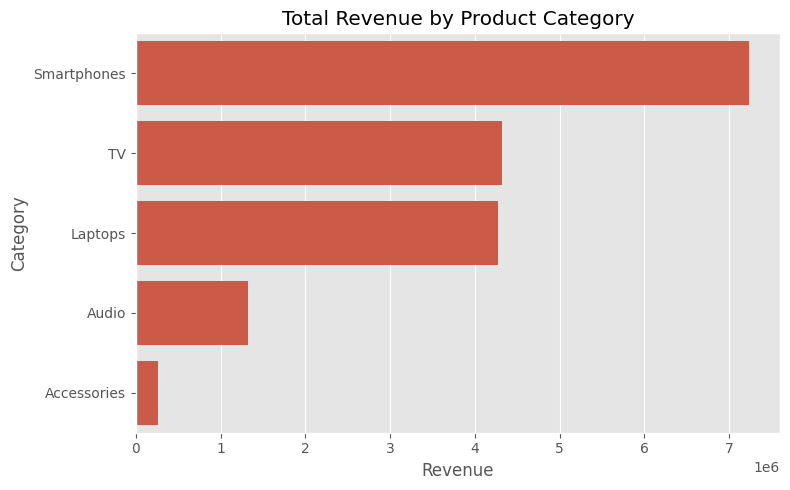

In [6]:
# Plot total revenue by category
plt.figure(figsize=(8, 5))
sns.barplot(x=revenue_by_category.values, y=revenue_by_category.index)
plt.title('Total Revenue by Product Category')
plt.xlabel('Revenue')
plt.ylabel('Category')
plt.tight_layout()
plt.show()


## 4. Monthly Sales Dynamics

Analyze revenue trends over time — by month.


In [7]:
# Calculate monthly revenue
monthly_revenue = sales_df.groupby('Month')['Revenue'].sum().sort_index()

# Display the result
monthly_revenue


Month
1      762000
2      874190
3      959840
4     1018570
5     1292090
6     1522410
7     1304460
8     1793510
9     1258470
10    2249450
11    1870870
12    2509180
Name: Revenue, dtype: int64

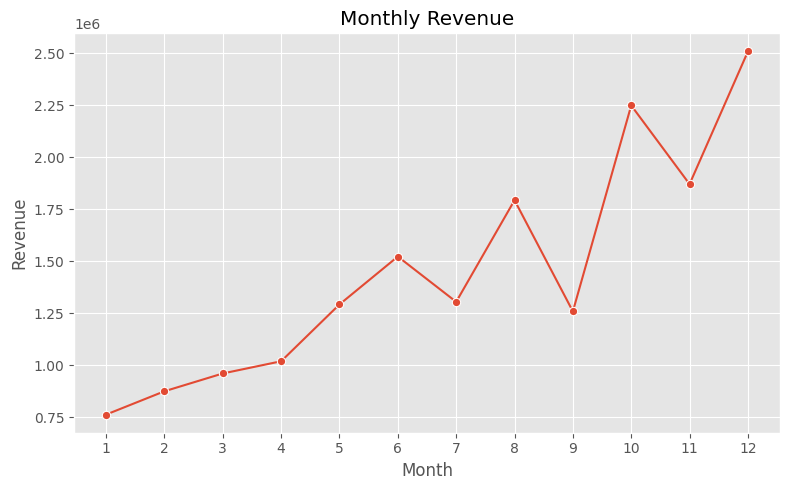

In [8]:
# Plot monthly revenue
plt.figure(figsize=(8, 5))
sns.lineplot(x=monthly_revenue.index, y=monthly_revenue.values, marker='o')
plt.title('Monthly Revenue')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(range(1, 13))  # ensure all 12 months are shown
plt.tight_layout()
plt.show()


## 5. Top 5 Best-Selling Products

Find the most frequently sold products by quantity.


In [9]:
# Find top 5 best-selling products by quantity
top_products = sales_df.groupby('Product')['Quantity'].sum().sort_values(ascending=False).head(5)

# Display the result
top_products


Product
USB-C Cable             78
Screen Protector        63
Xiaomi Redmi Note 10    51
Samsung Galaxy S21      40
iPhone 13               37
Name: Quantity, dtype: int64

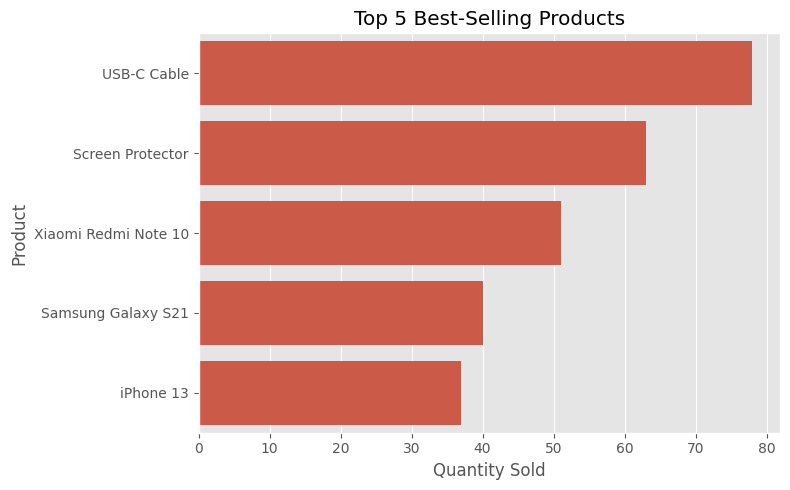

In [10]:
# Plot top 5 best-selling products
plt.figure(figsize=(8, 5))
sns.barplot(x=top_products.values, y=top_products.index)
plt.title('Top 5 Best-Selling Products')
plt.xlabel('Quantity Sold')
plt.ylabel('Product')
plt.tight_layout()
plt.show()


## Conclusion

1. **Smartphones** generated the highest total revenue among all product categories, making them the primary driver of income for the store.

2. There is a clear **seasonal trend** in sales: revenue peaks in **December**, with noticeable increases in **August** and **October**, likely due to holidays and back-to-school demand.

3. The most frequently sold items are **low-cost accessories** such as **USB-C Cables** and **Screen Protectors**, highlighting the importance of upselling add-on products.
